<a href="https://colab.research.google.com/github/Mokshitha08/XAI-Cultural-Heritage-App-Prediction/blob/main/XAI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading data from: /content/Cultural Heritage Apps Dataset.csv
Initial shape: (992, 25)
Dropping unnamed columns: ['Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']

Columns found:
['App Link on Google Play',
 'Application Name',
 'Number of Reviews',
 'Application Description',
 'Number of Characters in Description',
 'Overall Rate',
 'First Page Reviews',
 'Number of Characters in First Page Reviews',
 'Last Update',
 'Ending Date',
 'Number of Days Since Last Update',
 'App Size',
 'App Installs',
 'Version Required']
Regression target chosen: Number of Reviews
No price-like column found. Falling back to first text/object column: 'App Link on Google Play'
Dropped 876 rows with missing regression target. Remaining: 116
Text columns for TF-IDF: ['Application Name', 'Application Description', 'Number of Characters in Description', 'App Size', 'App Installs']
Numeric cols: 

/tmp/ipykernel_1887/140316383.py:172: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(med, inplace=True)


Preprocessor output shape: (116, 310) type: <class 'scipy.sparse._csr.csr_matrix'>

Running TruncatedSVD to reduce features -> n_components=100
Explained variance ratio (sum): 0.998925497231306
Final feature matrix shape (after SVD/reduction): (116, 100)

Training Linear Regression...
LinearRegression -> MSE: 70231555714.4171, R2: -0.0428
Training RandomForestRegressor (can take time)...
RandomForestRegressor -> MSE: 70228748647.5432, R2: -0.0428


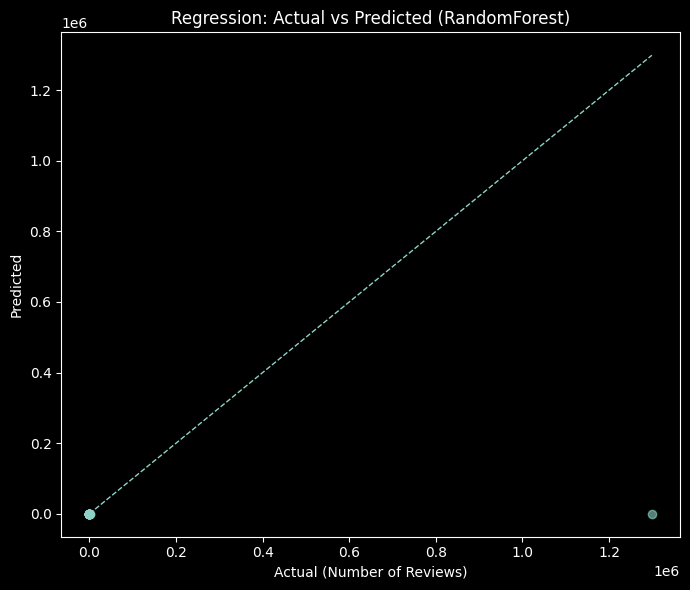

Saved regression models: linear_regression_model.joblib, random_forest_regressor.joblib

Classification classes: ['https://play.google.com/store/apps/details?id=air.com.dor.paris.vusiem', 'https://play.google.com/store/apps/details?id=air.com.lvr.paris.vusiem', 'https://play.google.com/store/apps/details?id=ask.brooklynmuseum.org', 'https://play.google.com/store/apps/details?id=au.com.ngv.ngvapp', 'https://play.google.com/store/apps/details?id=au.net.australianmuseum.scottsistersapp', 'https://play.google.com/store/apps/details?id=be.digipolis.ama', 'https://play.google.com/store/apps/details?id=ca.qc.mbam.mobile', 'https://play.google.com/store/apps/details?id=cat.mnac.cat', 'https://play.google.com/store/apps/details?id=co.theguru.dali', 'https://play.google.com/store/apps/details?id=co.theguru.sdmofa', 'https://play.google.com/store/apps/details?id=com.Cultural.Collections', 'https://play.google.com/store/apps/details?id=com.DigitalMind.DNMapp', 'https://play.google.com/store/apps/d

/tmp/ipykernel_1887/140316383.py:319: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


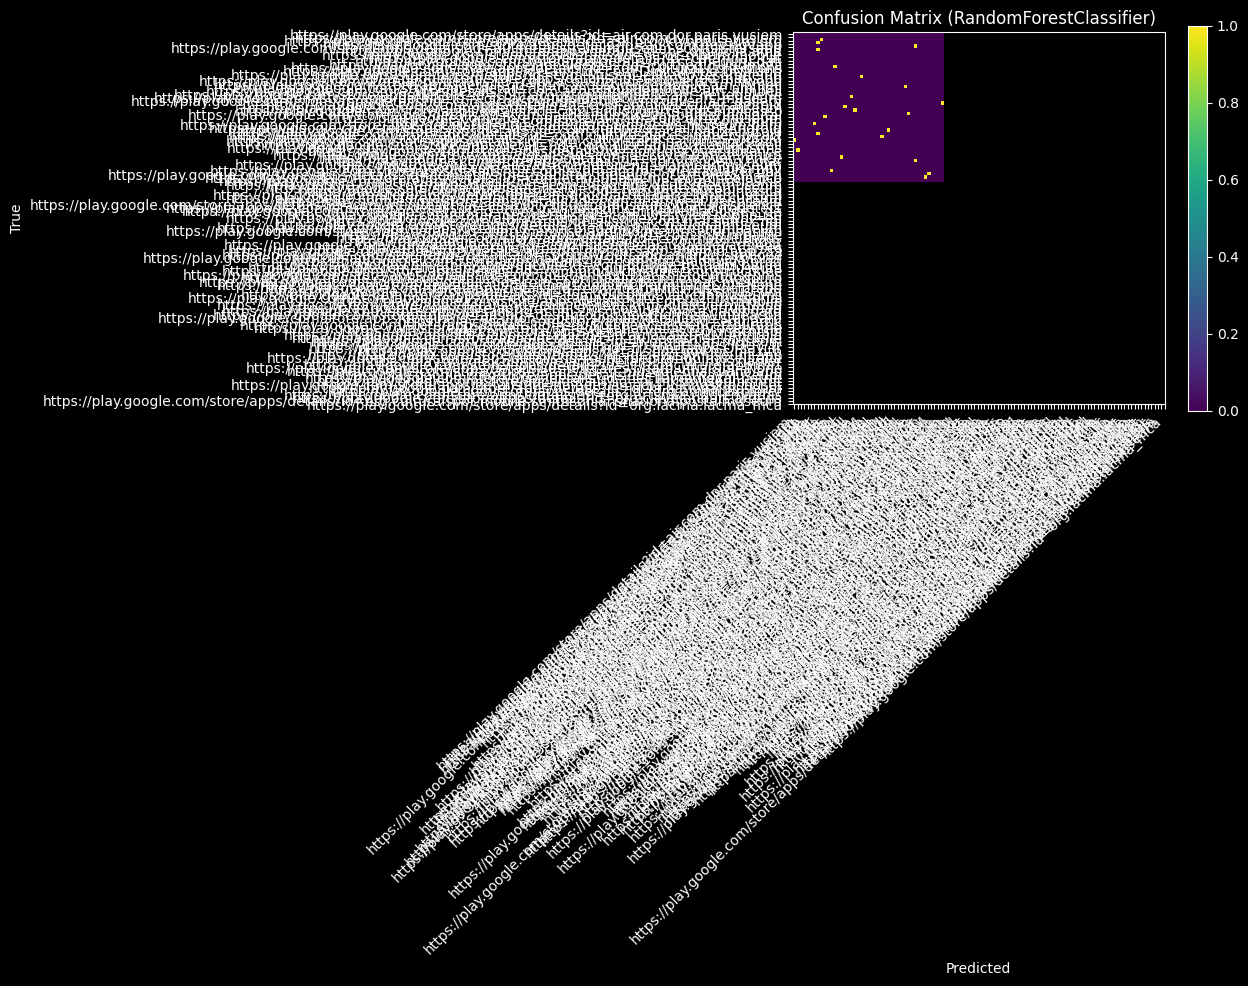

Saved classification models and label encoder.

--- SUMMARY ---
Rows used: 116
Regression target: Number of Reviews  (Linear R2: -0.0428, RF R2: -0.0428)
Classification target: App Link on Google Play  (classes: ['https://play.google.com/store/apps/details?id=air.com.dor.paris.vusiem', 'https://play.google.com/store/apps/details?id=air.com.lvr.paris.vusiem', 'https://play.google.com/store/apps/details?id=ask.brooklynmuseum.org', 'https://play.google.com/store/apps/details?id=au.com.ngv.ngvapp', 'https://play.google.com/store/apps/details?id=au.net.australianmuseum.scottsistersapp', 'https://play.google.com/store/apps/details?id=be.digipolis.ama', 'https://play.google.com/store/apps/details?id=ca.qc.mbam.mobile', 'https://play.google.com/store/apps/details?id=cat.mnac.cat', 'https://play.google.com/store/apps/details?id=co.theguru.dali', 'https://play.google.com/store/apps/details?id=co.theguru.sdmofa', 'https://play.google.com/store/apps/details?id=com.Cultural.Collections', 'https://p

In [2]:
import os
import re
import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from joblib import dump

# Dark plotting
plt.style.use("dark_background")

# -----------------------
# Config
# -----------------------
DATA_PATH = "/content/Cultural Heritage Apps Dataset.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
TFIDF_MAX_FEATURES = 200         # controls TF-IDF size
TOP_CAT_UNIQUE = 50             # keep top 50 categories per categorical column
SVD_MAX_COMPONENTS = 200        # max SVD components to reduce to

# -----------------------
# Helpers
# -----------------------
def safe_read_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return pd.read_csv(path, low_memory=False)

def detect_regression_target(columns):
    # look for likely names
    patterns = [r"number.*review", r"num.*review", r"\breviews?\b", r"\brating\b", r"\binstalls\b"]
    for p in patterns:
        for c in columns:
            if re.search(p, str(c), flags=re.I):
                return c
    return None

def detect_price_or_category(columns):
    price_patterns = [r"price", r"\bfree\b", r"\bpaid\b", r"cost", r"amount"]
    cat_patterns = [r"category", r"genre", r"type"]
    for p in price_patterns:
        for c in columns:
            if re.search(p, str(c), flags=re.I):
                return c, "price"
    for p in cat_patterns:
            if re.search(p, str(c), flags=re.I):
                return c, "category"
    # fallback to first object column
    return None, None

def map_price_to_free_paid(val):
    if pd.isna(val): return "unknown"
    s = str(val).strip().lower()
    if "free" in s: return "Free"
    # currency symbols or floating numeric >0
    if re.search(r'[\$\€\£\₹]', s):
        # try numeric parse
        nums = re.sub(r'[^\d\.]', '', s)
        try:
            num = float(nums) if nums else None
            if num is not None and num == 0:
                return "Free"
            return "Paid"
        except:
            return "Paid"
    # number embedded
    if re.search(r'\d', s):
        try:
            num = float(re.sub(r'[^\d\.]', '', s))
            return "Free" if num == 0 else "Paid"
        except:
            pass
    # default unknown -> treat as Paid (safer)
    return "Paid"

def text_clean(s):
    if pd.isna(s): return ""
    s = str(s)
    s = re.sub(r'http\S+|www\.\S+', ' ', s)
    s = re.sub(r'[^0-9A-Za-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip().lower()
    return s

# -----------------------
# Load data
# -----------------------
print("Loading data from:", DATA_PATH)
df = safe_read_csv(DATA_PATH)
print("Initial shape:", df.shape)

# Drop unnamed columns
unnamed = [c for c in df.columns if str(c).startswith("Unnamed")]
if unnamed:
    print("Dropping unnamed columns:", unnamed)
    df.drop(columns=unnamed, inplace=True, errors="ignore")

# Clean column names (strip)
df.columns = [c.strip() if isinstance(c, str) else c for c in df.columns]

print("\nColumns found:")
pprint.pprint(list(df.columns))

# -----------------------
# Target detection
# -----------------------
reg_target = detect_regression_target(df.columns)
if reg_target is None:
    # fallback to a numeric column with variance
    numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols_all:
        # pick numeric column with max variance other than all zeros
        variances = {c: df[c].astype(float).var() for c in numeric_cols_all}
        # sort
        sorted_vars = sorted(variances.items(), key=lambda x: - (x[1] if not np.isnan(x[1]) else -1))
        reg_target = sorted_vars[0][0]
    else:
        raise RuntimeError("No suitable numeric column found for regression target.")
print("Regression target chosen:", reg_target)

price_or_cat_col, col_type = detect_price_or_category(df.columns)
if price_or_cat_col:
    print(f"Detected classification candidate column: '{price_or_cat_col}' (type hint: {col_type})")
else:
    # fallback to any object column
    obj_cols = df.select_dtypes(include=['object']).columns.tolist()
    if not obj_cols:
        raise RuntimeError("No suitable column for classification found.")
    price_or_cat_col = obj_cols[0]
    col_type = "category"
    print(f"No price-like column found. Falling back to first text/object column: '{price_or_cat_col}'")

class_target = price_or_cat_col

# -----------------------
# Basic cleaning
# -----------------------
# Ensure regression target numeric
df[reg_target] = pd.to_numeric(df[reg_target], errors='coerce')
before = len(df)
df = df.dropna(subset=[reg_target])
after = len(df)
print(f"Dropped {before-after} rows with missing regression target. Remaining: {after}")

# Identify text columns (common names)
possible_text_cols = [c for c in df.columns if re.search(r"name|description|app|title", str(c), flags=re.I)]
text_cols = [c for c in possible_text_cols if c not in [reg_target, class_target]]
print("Text columns for TF-IDF:", text_cols)

# Numeric and categorical columns
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != reg_target]
# Exclude the classification target column from categorical features
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c not in [class_target, reg_target] and c not in text_cols]
print("Numeric cols:", numeric_cols)
print("Categorical cols:", cat_cols)

# Fill numeric missing with median
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    med = df[c].median() if not np.isnan(df[c].median()) else 0.0
    df[c].fillna(med, inplace=True)

# Clean/prepare class target
if col_type == "price":
    df[class_target] = df[class_target].apply(map_price_to_free_paid).astype(str)
else:
    df[class_target] = df[class_target].fillna("unknown").astype(str)

# Reduce cardinality of categorical columns (keep top N)
for c in cat_cols:
    top = df[c].value_counts().nlargest(TOP_CAT_UNIQUE).index
    df[c] = df[c].where(df[c].isin(top), other="__other__").astype(str)

# Combine text columns into single 'text_all' column for TF-IDF
if text_cols:
    df['text_all'] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1).apply(text_clean)
else:
    df['text_all'] = ""  # empty

# -----------------------
# Preprocessing pipelines
# -----------------------
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='__missing__')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer: numeric, categorical, text (tfidf)
transformers = []
if numeric_cols:
    transformers.append(('num', num_pipeline, numeric_cols))
if cat_cols:
    transformers.append(('cat', cat_pipeline, cat_cols))
# Tfidf on combined text_all
transformers.append(('text', TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=(1,2)), 'text_all'))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# Fit-transform to produce a sparse matrix (or array)
print("\nFitting preprocessor (this may take a few seconds)...")
X_sparse = preprocessor.fit_transform(df)
print("Preprocessor output shape:", getattr(X_sparse, "shape", None), "type:", type(X_sparse))

# -----------------------
# Dimensionality reduction (TruncatedSVD) for dense models
# -----------------------
# Determine SVD components safely
n_samples = X_sparse.shape[0]
n_features = X_sparse.shape[1] if len(X_sparse.shape) > 1 else 1
max_comp = min(SVD_MAX_COMPONENTS, n_features, max(1, n_samples - 1))
n_components = max(1, min(max_comp, 100))  # keep it reasonable

print(f"\nRunning TruncatedSVD to reduce features -> n_components={n_components}")
if n_features <= 1 or n_samples <= 1:
    # fallback: convert to dense (tiny dataset)
    X = X_sparse.toarray() if hasattr(X_sparse, "toarray") else np.array(X_sparse)
else:
    svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    X = svd.fit_transform(X_sparse)
    print("Explained variance ratio (sum):", svd.explained_variance_ratio_.sum())

# Final feature matrix
print("Final feature matrix shape (after SVD/reduction):", X.shape)

# -----------------------
# Regression: prepare target and split
# -----------------------
y_reg = df[reg_target].astype(float).values
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Train Linear Regression
print("\nTraining Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
preds_lr = lr.predict(X_test_r)
mse_lr = mean_squared_error(y_test_r, preds_lr)
r2_lr = r2_score(y_test_r, preds_lr)
print(f"LinearRegression -> MSE: {mse_lr:.4f}, R2: {r2_lr:.4f}")

# Train RandomForestRegressor
print("Training RandomForestRegressor (can take time)...")
rfr = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rfr.fit(X_train_r, y_train_r)
preds_rfr = rfr.predict(X_test_r)
mse_rfr = mean_squared_error(y_test_r, preds_rfr)
r2_rfr = r2_score(y_test_r, preds_rfr)
print(f"RandomForestRegressor -> MSE: {mse_rfr:.4f}, R2: {r2_rfr:.4f}")

# Plot Actual vs Predicted (RandomForest)
plt.figure(figsize=(7,6))
plt.scatter(y_test_r, preds_rfr, alpha=0.6)
maxv = max(np.nanmax(y_test_r), np.nanmax(preds_rfr))
plt.plot([0, maxv], [0, maxv], linestyle="--", linewidth=1)
plt.xlabel(f"Actual ({reg_target})")
plt.ylabel("Predicted")
plt.title("Regression: Actual vs Predicted (RandomForest)")
plt.tight_layout()
plt.show()

# Save regression models
dump(lr, "linear_regression_model.joblib")
dump(rfr, "random_forest_regressor.joblib")
print("Saved regression models: linear_regression_model.joblib, random_forest_regressor.joblib")

# -----------------------
# Classification
# -----------------------
y_cl_raw = df[class_target].fillna("unknown").astype(str)
le = LabelEncoder()
y_cl = le.fit_transform(y_cl_raw)
print("\nClassification classes:", list(le.classes_))

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_cl, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Logistic Regression
print("\nTraining LogisticRegression...")
clf_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_lr.fit(X_train_c, y_train_c)
preds_clf_lr = clf_lr.predict(X_test_c)
acc_lr = accuracy_score(y_test_c, preds_clf_lr)
f1_lr = f1_score(y_test_c, preds_clf_lr, average='weighted')
print(f"LogisticRegression -> Accuracy: {acc_lr:.4f}, F1 (weighted): {f1_lr:.4f}")

# RandomForestClassifier
print("Training RandomForestClassifier...")
clf_rfc = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
clf_rfc.fit(X_train_c, y_train_c)
preds_clf_rfc = clf_rfc.predict(X_test_c)
acc_rfc = accuracy_score(y_test_c, preds_clf_rfc)
f1_rfc = f1_score(y_test_c, preds_clf_rfc, average='weighted')
print(f"RandomForestClassifier -> Accuracy: {acc_rfc:.4f}, F1 (weighted): {f1_rfc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_c, preds_clf_rfc)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (RandomForestClassifier)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.tight_layout()
plt.show()

# ROC for binary
if len(le.classes_) == 2:
    probs = clf_rfc.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Save classification models & label encoder
dump(clf_lr, "logistic_classification_model.joblib")
dump(clf_rfc, "random_forest_classifier.joblib")
dump(le, "label_encoder_for_class.joblib")
print("Saved classification models and label encoder.")

# -----------------------
# Summary
# -----------------------
print("\n--- SUMMARY ---")
print(f"Rows used: {len(df)}")
print(f"Regression target: {reg_target}  (Linear R2: {r2_lr:.4f}, RF R2: {r2_rfr:.4f})")
print(f"Classification target: {class_target}  (classes: {list(le.classes_)})  (RF acc: {acc_rfc:.4f})")
print("Models are saved in current working directory.")